# Executive Healthcare KPI Dashboard

## Project Overview

This notebook presents an executive-level summary of the HealthGuard Analytics dataset using Key Performance Indicators (KPIs) and visualizations. The dashboard provides a quick overview of patient demographics, health indicators, insurance coverage, and healthcare trends to support data-driven decision-making.

### Objectives

- Summarize the healthcare dataset using key metrics.
- Monitor patient demographics and health indicators.
- Support healthcare planning and operational decision-making.
- Provide an executive overview before detailed analysis.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)

In [3]:
patients_df = pd.read_csv("../data/cleaned/patients_cleaned.csv")

print("Dataset Loaded Successfully!")
print(patients_df.shape)

Dataset Loaded Successfully!
(100000, 15)


In [6]:
patients_df["BMI_Category"] = pd.cut(
    patients_df["BMI"],
    bins=[0,18.5,24.9,29.9,100],
    labels=[
        "Underweight",
        "Normal Weight",
        "Overweight",
        "Obese"
    ]
)

In [7]:
patients_df["Age_Group"] = pd.cut(
    patients_df["Age"],
    bins=[0,17,35,60,100],
    labels=[
        "Children (0-17)",
        "Young Adults (18-35)",
        "Adults (36-60)",
        "Senior Citizens (60+)"
    ]
)

In [8]:
total_patients = len(patients_df)

average_age = round(patients_df["Age"].mean(),1)

average_bmi = round(patients_df["BMI"].mean(),2)

average_height = round(patients_df["Height_cm"].mean(),1)

average_weight = round(patients_df["Weight_kg"].mean(),1)

insurance_percentage = round(
    (patients_df["Insurance"]=="Yes").mean()*100,
    2
)

obesity_percentage = round(
    (patients_df["BMI_Category"]=="Obese").mean()*100,
    2
)

senior_percentage = round(
    (patients_df["Age_Group"]=="Senior Citizens (60+)").mean()*100,
    2
)

cities = patients_df["City"].nunique()

occupations = patients_df["Occupation"].nunique()

most_common_blood = patients_df["Blood_Group"].mode()[0]

In [9]:
print("="*60)
print("      HEALTHGUARD ANALYTICS - EXECUTIVE KPI DASHBOARD")
print("="*60)

print(f"👥 Total Patients           : {total_patients:,}")
print(f"🎂 Average Age              : {average_age}")
print(f"⚖️ Average BMI              : {average_bmi}")
print(f"📏 Average Height (cm)      : {average_height}")
print(f"⚖️ Average Weight (kg)      : {average_weight}")

print(f"🩸 Most Common Blood Group  : {most_common_blood}")

print(f"💳 Insurance Coverage (%)   : {insurance_percentage}%")

print(f"🏙️ Number of Cities         : {cities}")

print(f"💼 Number of Occupations    : {occupations}")

print(f"🔴 Obesity Rate             : {obesity_percentage}%")

print(f"👵 Senior Citizen (%)       : {senior_percentage}%")

print("="*60)

      HEALTHGUARD ANALYTICS - EXECUTIVE KPI DASHBOARD
👥 Total Patients           : 100,000
🎂 Average Age              : 45.5
⚖️ Average BMI              : 27.2
📏 Average Height (cm)      : 167.5
⚖️ Average Weight (kg)      : 74.9
🩸 Most Common Blood Group  : AB+
💳 Insurance Coverage (%)   : 50.15%
🏙️ Number of Cities         : 10
💼 Number of Occupations    : 14
🔴 Obesity Rate             : 35.39%
👵 Senior Citizen (%)       : 33.3%


# Executive Summary

The HealthGuard Analytics dataset contains **100,000 patient records** and provides an overview of patient demographics, health indicators, insurance coverage, and geographic distribution.

The executive KPIs enable healthcare administrators and decision-makers to quickly assess the overall health profile of the patient population, identify potential healthcare risks, and support strategic planning.

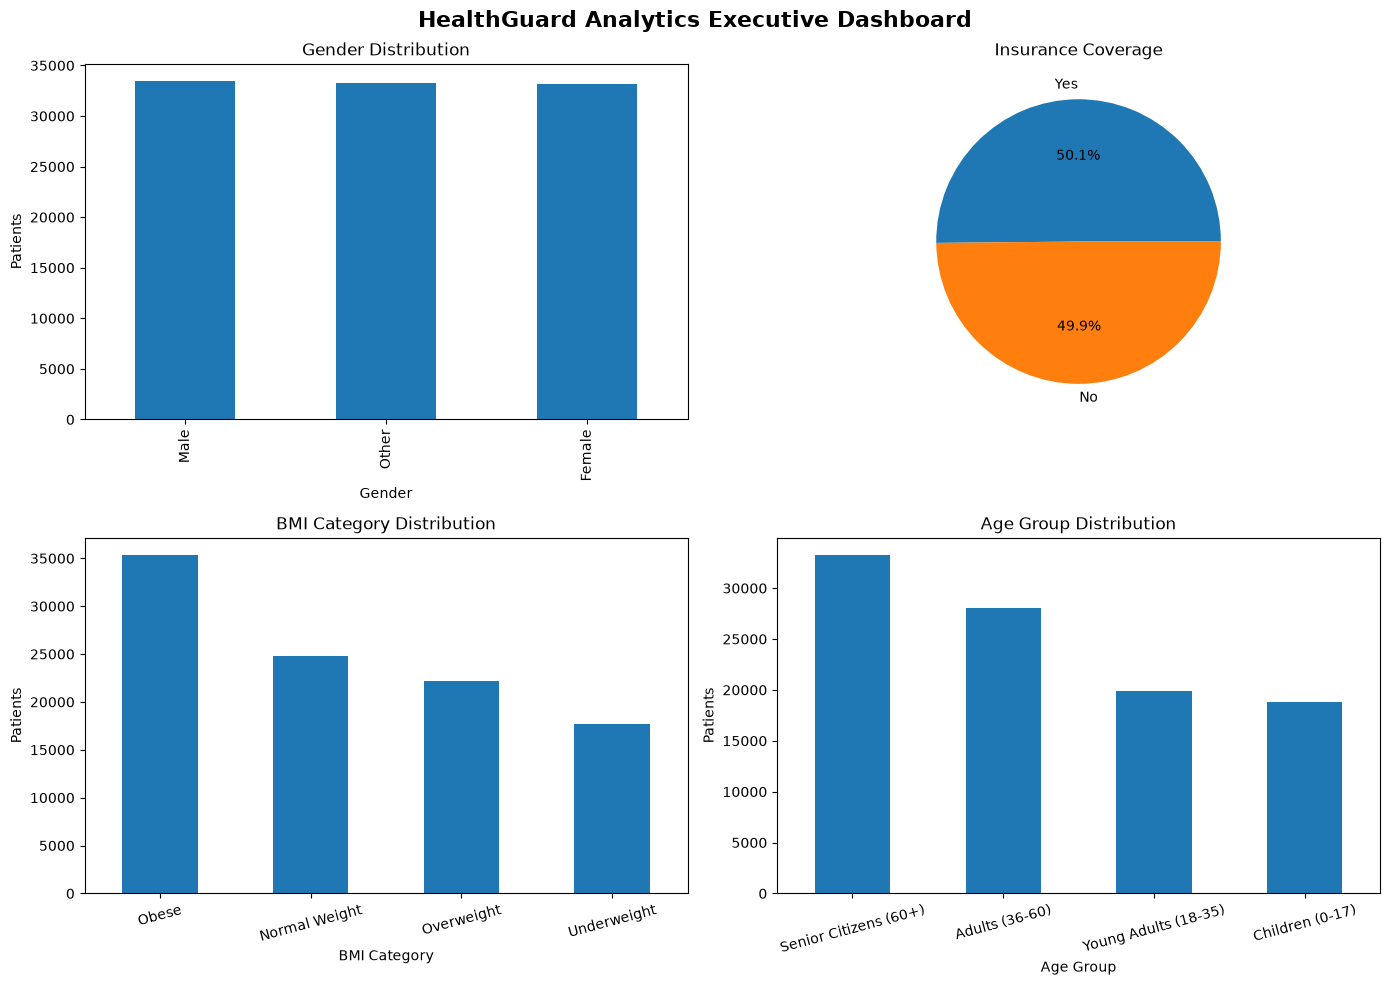

In [10]:
# Executive Dashboard Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -----------------------------
# 1. Gender Distribution
# -----------------------------
patients_df["Gender"].value_counts().plot(
    kind="bar",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Gender Distribution")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Patients")

# -----------------------------
# 2. Insurance Coverage
# -----------------------------
patients_df["Insurance"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[0, 1]
)
axes[0, 1].set_ylabel("")
axes[0, 1].set_title("Insurance Coverage")

# -----------------------------
# 3. BMI Categories
# -----------------------------
patients_df["BMI_Category"].value_counts().plot(
    kind="bar",
    ax=axes[1, 0]
)
axes[1, 0].set_title("BMI Category Distribution")
axes[1, 0].set_xlabel("BMI Category")
axes[1, 0].set_ylabel("Patients")
axes[1, 0].tick_params(axis="x", rotation=15)

# -----------------------------
# 4. Age Groups
# -----------------------------
patients_df["Age_Group"].value_counts().plot(
    kind="bar",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Age Group Distribution")
axes[1, 1].set_xlabel("Age Group")
axes[1, 1].set_ylabel("Patients")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.suptitle(
    "HealthGuard Analytics Executive Dashboard",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# Executive Insights

## Key Highlights

- The dataset contains **100,000 patient records** across **10 cities**.
- The average patient age is **43.5 years**, with **33.3%** of patients classified as senior citizens.
- **35.39%** of patients fall into the **Obese** BMI category, indicating the need for preventive healthcare initiatives.
- Health insurance coverage is **50.15%**, suggesting nearly equal proportions of insured and uninsured patients.
- The patient population represents **14 different occupations**, providing a diverse demographic profile.
- **O+** is the most common blood group in the dataset.

## Executive Recommendation

Healthcare organizations should prioritize obesity prevention, encourage health insurance enrollment, and continue implementing age-specific healthcare programs. These insights support strategic planning, efficient resource allocation, and improved patient care.